# Why churning concepts spread — Part A scoring + Exp11 completion (demo)

This notebook is a runnable walk-through of `method.py` from **iteration-5, experiment 15** of the study
*"Exploring emerging scientific concepts through evolving knowledge networks"* (OpenAlex concept co-occurrence networks).

`method.py` is the **entry point** of the experiment. It does two things:

1. **Runs the pipeline stages** (`run_stages`). Each stage is a separate script: the sealed Exp11 within-concept closure test (PPML body models, a Sun-Abraham event study, sequence tests, H-P1), the HOME partner builds, sealing, unit tests, Part-A partner-class scoring and Part-B trait stability. On 4 CPUs this takes about **3 hours** and needs multi-GB upstream caches, so the notebook does **not** re-run these stages. Their small JSON outputs ship in `mini_demo_data.json` (`stage_results`).
2. **Assembles the deliverables:**
   * `exp11_completion()` collects the Exp11 completion verdicts (H-M1/H-M2 PPML per body, H-M3/H-M5, event study H-M4, sequence H-S1, H-P1).
   * `method_out()` runs **5-fold concept-level cross-validated ridge regression** within each evaluation body. It predicts the future diffusion outcome `O2r_m50` from the size/reach baseline **B5** alone, then B5 plus one of `NOVCHURN_home` (neighbourhood novelty × churn in the concept's home field), the 12 HOME **partner-class parts**, or `OPEN_home`. A paired concept bootstrap gives the Spearman gain of NOVCHURN.

The demo data holds **25 concepts per body** (DEV, OLD_HELDOUT, COHORT_2010_14, COHORT_2015_17) instead of the full ~7,800 concepts. The CV numbers are therefore noisy. The final cell compares them with the full-run reference metrics.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, sklearn, scipy, matplotlib, pyarrow — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports
The original import block of `method.py`. The `lib_iter5` path insertion and `from common_iter5 import ...` are replaced by the next cell, which inlines the few helpers `method.py` uses. matplotlib is added for the final visualization.

In [2]:
from __future__ import annotations

import argparse
import json
import os
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt  # notebook addition: visualization

### Helpers copied from `lib_iter5/common_iter5.py`
Only the names `method.py` imports: `B5`, `SEED`, `jdump` (NaN-safe JSON dump), `setup_logger`, `add_deviation`. Paths point at the notebook's working directory instead of the run root.
`B5` is the preregistered **5-feature baseline**: early log-volume, early growth, off-home share, field entropy and field reach.

In [3]:
import math

WS = Path(".").resolve()
DATA, RES, LOGS, FIGS = WS / "data", WS / "results", WS / "logs", WS / "figures"
for _d in (RES, LOGS):
    _d.mkdir(parents=True, exist_ok=True)
E8 = WS / "E8"  # upstream EXP8 artifact (only its concept-name table is used; shipped in mini_demo_data.json)

SEED = 20260929
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
HELD = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]


def setup_logger(name: str):
    from loguru import logger
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")
    return logger


def _clean(o):
    if isinstance(o, dict):
        return {str(k): _clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_clean(v) for v in o]
    if isinstance(o, np.ndarray):
        return _clean(o.tolist())
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, (np.floating, float)):
        return None if not math.isfinite(float(o)) else float(o)
    return o


def jdump(obj, path: Path) -> None:
    Path(path).write_text(json.dumps(_clean(obj), indent=1, default=str))


def add_deviation(key: str, text: str) -> None:
    p = RES / "deviations.json"
    d = json.loads(p.read_text()) if p.exists() else {}
    d[key] = text
    p.write_text(json.dumps(d, indent=1))

## Data loading
Loads `mini_demo_data.json` from GitHub, with a local fallback. It contains:
* `partA_features_exp5` has 75 concepts, 25 each from the DEV, OLD_HELDOUT and COHORT_2010_14 bodies. Each row holds B5, NOVCHURN_home, OPEN_home, the partner-class parts and the outcome `O2r_m50`, sampled so that every field group appears.
* `partA_features_cohort` has 25 concepts from the 2015–17 newborn cohort.
* `analysis_table_names` is the EXP8 `ci → name` table for the selected concepts.
* `stage_results` holds the JSON outputs of the heavy stages (seal verification, Exp11 FE body models, event study, sequence tests, H-P1, unit tests).
* `reference_cv_metrics_full_run` holds the CV metrics of the original full run.

In [4]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-5/experiment-15/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [5]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items() if k != "description"})

{'partA_features_exp5': 75, 'partA_features_cohort': 25, 'analysis_table_names': 75, 'stage_results': 7, 'reference_cv_metrics_full_run': 4}


## Config
The tunable parameters of `method_out()`. The values from the original script are noted in the comments. The ridge step is cheap on the 100-concept demo, so the original values are used.

In [6]:
N_FOLDS = 5          # concept-level CV folds per body (original: 5)
RIDGE_ALPHA = 1.0    # ridge penalty (original: 1.0)
N_BOOT = 1000        # paired concept bootstraps for the NOVCHURN Spearman gain (original: 1000)
P_SAMPLE_PER_BODY = 2000  # Exp11 panel-prediction rows sampled per body (original: 2000; that dataset is not in the demo data)
RUN_STAGES = False   # original: stages run unless outputs exist (~3 h, needs upstream caches) -> precomputed here

## Pipeline stages (not executed in the demo)
This is the original stage table and runner. Each entry is a script, its arguments and the output file whose presence skips the stage. `run_stages` pins BLAS/OpenMP/numba to **one thread per process**, which is the fix for the Exp11 event-study crash. The notebook only prints the table because `RUN_STAGES = False`. The outputs of these stages are in `data["stage_results"]`.

In [7]:
X11 = WS / "exp11_code"
PY = sys.executable
STAGES = [
    ("setup", ["setup_exp11.py"], RES / "seal_verification.json"),
    ("completion", ["exp11_code/run_completion.py", "--workers", "{w}"], X11 / "results/fe_results_completed.json"),
    ("event_study", ["exp11_code/run_event_study.py", "--workers", "{w}"], X11 / "results/event_study.json"),
    ("sequence", ["exp11_code/sequence.py", "--boot", "300", "--workers", "{w}"], X11 / "results/sequence_tests.json"),
    ("partners_c4", ["exp11_code/run_partners.py"], X11 / "results/H_P1.json"),
    ("home_exp5", ["partners_home.py", "--frame", "exp5", "--workers", "{w}"], DATA / "partner_home_components_exp5.parquet"),
    ("home_cohort", ["partners_home.py", "--frame", "cohort", "--workers", "{w}"], DATA / "partner_home_components_cohort.parquet"),
    ("home_retest", ["partners_home.py", "--frame", "retest", "--workers", "{w}"], DATA / "partner_home_components_retest.parquet"),
    ("freeze", ["seal_iter5.py", "freeze"], RES / "frozen_spec_iter5.json"),
    ("seal", ["seal_iter5.py", "seal"], WS / "logs/seal_iter5.log"),
    ("tests", ["tests/test_iter5.py"], RES / "unit_tests_iter5.json"),
    ("score_partA", ["score_partA.py", "--workers", "{w}"], RES / "partner_classes.json"),
    ("trait", ["trait_stability.py"], RES / "trait_stability.json"),
]


def run_stages(workers: int, force: bool, logger) -> None:
    env = dict(os.environ, OPENBLAS_NUM_THREADS="1", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1", NUMBA_NUM_THREADS="1")
    for name, cmd, out in STAGES:
        if out.exists() and not force:
            logger.info(f"stage {name}: output exists, skipped")
            continue
        c = [PY] + [x.format(w=workers) for x in cmd]
        logger.info(f"stage {name}: {' '.join(c[1:])}")
        t = time.time()
        r = subprocess.run(c, cwd=WS, env=env)
        if r.returncode != 0:
            raise RuntimeError(f"stage {name} failed with exit code {r.returncode}")
        logger.info(f"stage {name} done in {(time.time()-t)/60:.1f} min")


for name, cmd, out in STAGES:
    print(f"{name:<12} {' '.join(cmd):<60} -> {out.relative_to(WS)}")

setup        setup_exp11.py                                               -> results/seal_verification.json
completion   exp11_code/run_completion.py --workers {w}                   -> exp11_code/results/fe_results_completed.json
event_study  exp11_code/run_event_study.py --workers {w}                  -> exp11_code/results/event_study.json
sequence     exp11_code/sequence.py --boot 300 --workers {w}              -> exp11_code/results/sequence_tests.json
partners_c4  exp11_code/run_partners.py                                   -> exp11_code/results/H_P1.json
home_exp5    partners_home.py --frame exp5 --workers {w}                  -> data/partner_home_components_exp5.parquet
home_cohort  partners_home.py --frame cohort --workers {w}                -> data/partner_home_components_cohort.parquet
home_retest  partners_home.py --frame retest --workers {w}                -> data/partner_home_components_retest.parquet
freeze       seal_iter5.py freeze                                         

## Exp11 completion: assembling the sealed closure-test verdicts
`exp11_completion()` gathers the outputs of the Exp11 stages into one summary:
* **G0 / G1 gates:** the sealed hashes match, the rebuilt panel equals the cache, and the DEV estimates reproduce.
* **Body models (H-M1 density, H-M2 OPEN_home):** PPML fixed-effects estimates with CRV1 and bootstrap CIs, for DEV, OLD_HELDOUT and the 2010–14 cohort.
* **Event study (H-M4):** Sun-Abraham estimates with pre-trend Wald tests, the Roth detectable slope and an event-date placebo.
* **Sequence (H-S1):** do multi-community concepts spread without an earlier home-prominence peak?
* **H-P1:** the preregistered partner test.

The only change from the original is the `j(...)` loader. It reads from `data["stage_results"]` instead of from files.

In [8]:
# ----------------------------------------------------------------------------- exp11 completion
def exp11_completion(logger) -> dict:
    j = lambda k: data["stage_results"].get(k)  # noqa: E731  (original: json.loads(p.read_text()) if p.exists() else None)
    seal = j("seal_verification")
    fe = j("fe_results_completed")
    es = j("event_study")
    sq = j("sequence_tests")
    hp = j("H_P1")
    ut = j("unit_tests")
    dv = j("deviations") or {}
    out: dict = {"dev_verdict": "DEV verdict unchanged: NOT SUPPORTED",
                 "seal_verification": {k: seal[k] for k in ("frozen_spec_ok", "n_files", "n_ok", "G0_pass", "mismatches")}
                 if seal else None}
    if fe:
        out["panel_rebuild_equal_to_cache"] = fe["panel_rebuild_check"]["equal"]
        out["G1_dev_reproduction"] = fe["G1_dev_reproduction"]["pass"]
        bm = {}
        for b in ("DEV", "OLD_HELDOUT", "COHORT"):
            r = fe[b]
            bs = r.get("bootstrap", {})
            bm[b] = {"n_rows": r["n_rows"], "n_concepts": r["n_concepts"],
                     "H_M1_density": {"b": r["H_M1_density"]["b"], "ci_crv1": r["H_M1_density"]["ci"],
                                      "ci_boot": bs.get("b_density", {}).get("ci"),
                                      "pct_per_within_sd": r["H_M1_density"]["pct_per_within_sd"]},
                     "H_M2_OPEN_home": {"b": r["H_M2_open"]["b"], "ci_crv1": r["H_M2_open"]["ci"],
                                        "ci_boot": bs.get("b_open", {}).get("ci"),
                                        "pct_per_within_sd": r["H_M2_open"]["pct_per_within_sd"]},
                     "joint": r.get("joint"), "lpm_density": r.get("lpm_density"), "lpm_open": r.get("lpm_open"),
                     "DL_density": r.get("DL_density"), "DL_OPEN_home": r.get("DL_OPEN_home"),
                     "n_boot": bs.get("n_boot")}
        out["body_models"] = bm
        out["H_M3"] = fe.get("H_M3")
        out["H_M5"] = fe.get("H_M5")
        out["robustness_DEV"] = fe.get("robustness_DEV")
        out["prediction_deviance"] = fe.get("prediction_deviance")
    if es:
        E = {}
        for b in ("DEV", "OLD_HELDOUT", "COHORT"):
            if b not in es:
                continue
            E[b] = {"n_eligible": es[b].get("n_eligible"), "n_treated": es[b].get("n_treated")}
            for v, r in es[b].items():
                if isinstance(r, dict) and "att" in r:
                    E[b][v] = {k: r.get(k) for k in ("att", "ci", "mean_lag_0_2", "lag02_ci", "pretrend_wald",
                                                     "roth_detectable_slope_80pct", "max_abs_lead", "lead_small_vs_lag",
                                                     "n_treated", "n", "n_boot_ok", "treated_rows_by_e",
                                                     "crosscheck_pyfixest_max_abs_diff")}
            if "placebo_event_date" in es[b]:
                E[b]["placebo_event_date"] = es[b]["placebo_event_date"]
        out["event_study"] = E
        out["H_M4"] = es.get("H_M4")
        out["event_study_timing_gate"] = es.get("timing_gate")
    if sq:
        out["H_S1"] = {b: sq[b]["share_test"] for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["H_S1_excl_Med"] = {b: sq[b]["share_test_excl_Med"] for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["sequence_survival"] = {b: {"logrank": sq[b]["survival"]["logrank"], "cox": sq[b]["survival"]["cox"],
                                        "km_median": {k: v["median"] for k, v in sq[b]["survival"]["km"].items()}}
                                    for b in ("DEV", "OLD_HELDOUT", "COHORT", "ALL") if b in sq}
        out["sequence_event_studies"] = {k: {kk: v.get(kk) for kk in ("att", "ci", "mean_lag_0_2", "lag02_ci",
                                                                      "pretrend_wald", "n_treated")}
                                         for k, v in sq.items() if k.startswith("es_")}
        out["H_S1_prior_estimate_Exp12"] = {"HR": 0.47, "note": "Exp12 independent prior estimate, cited, not recomputed"}
    if hp:
        out["H_P1"] = hp
    out["exp11_unit_tests_rerun"] = {k: v.get("pass") for k, v in ut.items() if isinstance(v, dict)} if ut else None
    out["deviations_exp11_code"] = dv
    return out

## Concept-CV ridge
`cv_ridge()` produces out-of-fold predictions. In each fold it median-imputes the numeric features (with missingness indicators), z-scores them on the training part only, adds one-hot fixed effects for `t0` (entry year) and field `group`, and fits a ridge. Folds are over concepts, so a concept is never in the training and test parts at once.

In [9]:
# ----------------------------------------------------------------------------- method_out
def cv_ridge(d: pd.DataFrame, feats: list[str], y: str, folds: np.ndarray, cats: list[str]) -> np.ndarray:
    from sklearn.linear_model import Ridge
    pred = np.full(len(d), np.nan)
    Xn = d[feats].to_numpy(float)
    C = pd.get_dummies(d[cats].astype(str), drop_first=True).to_numpy(float) if cats else np.zeros((len(d), 0))
    yv = d[y].to_numpy(float)
    for k in np.unique(folds):
        tr, te = folds != k, folds == k
        med = np.nanmedian(Xn[tr], axis=0)
        miss = ~np.isfinite(Xn)
        Xi = np.where(miss, med, Xn)
        mu, sd = Xi[tr].mean(0), Xi[tr].std(0)
        sd[sd < 1e-12] = 1
        Z = np.c_[(Xi - mu) / sd, miss[:, [j for j in range(Xn.shape[1]) if miss[:, j].any()]].astype(float), C]
        m = Ridge(alpha=RIDGE_ALPHA).fit(Z[tr], yv[tr])  # original: alpha=1.0
        pred[te] = m.predict(Z[te])
    return pred

## `method_out()`: B5 baseline vs B5 + NOVCHURN / partner classes / OPEN_home
For each evaluation body (the three EXP5 bodies plus the 2015–17 cohort) this:
1. keeps concepts with a finite outcome `O2r_m50` and a complete B5,
2. draws random fold ids with the fixed seed,
3. fits four CV ridge models: **B5**, **B5 + NOVCHURN_home**, **B5 + 12 partner-class parts** (novelty/churn split by METHOD vs DOMAIN partner, new vs old community, low vs high null degree, mixed vs pure carrier papers, dropped/added churn) and **B5 + OPEN_home**,
4. scores the out-of-fold Spearman and RMSE, and bootstraps the paired Spearman gain of NOVCHURN over B5 by resampling concepts,
5. writes one example per concept in the `exp_gen_sol_out` schema.

The changes from the original: the parquet reads become DataFrames from `data`, and the config variables replace the fold count and bootstrap count. The optional Exp11 panel-prediction dataset is not part of the demo data, so that branch is skipped.

In [10]:
def method_out(logger) -> dict:
    from scipy import stats
    D5 = pd.DataFrame(data["partA_features_exp5"])    # original: pd.read_parquet(DATA / "partA_features_exp5.parquet")
    Dc = pd.DataFrame(data["partA_features_cohort"])  # original: pd.read_parquet(DATA / "partA_features_cohort.parquet")
    D5["label"], D5["body_name"] = D5.ci.astype(str), D5.body
    A = pd.DataFrame(data["analysis_table_names"])    # original: pd.read_parquet(E8 / "data/analysis_table.parquet", columns=["ci", "name"])
    D5 = D5.merge(A, on="ci", how="left")
    Dc["body_name"] = "COHORT_2015_17"
    parts = ["nov_type_METHOD", "nov_type_DOMAIN", "ch_type_METHOD", "ch_type_DOMAIN", "ner_comm_new", "ner_comm_old",
             "nov_deg_low", "nov_deg_high", "ner_carrier_mixed", "ner_carrier_pure", "chd_all", "cha_all"]
    meta_cols = ["NOVCHURN_home", "NOV_res", "edge_persistence", "new_edge_rate", "churn", "bridging_share_home",
                 "OPEN_home", "M", "n1", "n_home_early"] + parts
    rows, metrics = [], {}
    for body, d in list(D5.groupby("body_name")) + [("COHORT_2015_17", Dc)]:
        d = d[np.isfinite(d.O2r_m50) & d[B5].notna().all(1)].reset_index(drop=True)
        folds = np.random.default_rng(SEED).integers(0, N_FOLDS, len(d))  # original: integers(0, 5, len(d))
        cats = ["t0"] + (["group"] if "group" in d and d.group.nunique() > 1 else [])
        p0 = cv_ridge(d, B5, "O2r_m50", folds, cats)
        p1 = cv_ridge(d, B5 + ["NOVCHURN_home"], "O2r_m50", folds, cats)
        p2 = cv_ridge(d, B5 + parts, "O2r_m50", folds, cats)
        p3 = cv_ridge(d, B5 + ["OPEN_home"], "O2r_m50", folds, cats)
        y = d.O2r_m50.to_numpy(float)
        metrics[body] = {"n": int(len(d))}
        for nm, p in (("B5", p0), ("B5_plus_NOVCHURN", p1), ("B5_plus_partner_classes", p2), ("B5_plus_OPEN_home", p3)):
            metrics[body][nm] = {"spearman_oof": float(stats.spearmanr(p, y)[0]),
                                 "rmse_oof": float(np.sqrt(np.mean((p - y) ** 2)))}
        # paired concept bootstrap of the OOF Spearman gain (NOVCHURN vs baseline)
        rng = np.random.default_rng(SEED)
        g = []
        for _ in range(N_BOOT):  # original: range(1000)
            i = rng.integers(0, len(y), len(y))
            g.append(stats.spearmanr(p1[i], y[i])[0] - stats.spearmanr(p0[i], y[i])[0])
        metrics[body]["gain_NOVCHURN_spearman"] = {"est": metrics[body]["B5_plus_NOVCHURN"]["spearman_oof"] -
                                                   metrics[body]["B5"]["spearman_oof"],
                                                   "ci": [float(np.percentile(g, 2.5)), float(np.percentile(g, 97.5))]}
        for i, r in d.iterrows():
            inp = {"concept": str(r.get("name", "")), "ci": int(r.ci), "body": body, "t0": int(r.t0),
                   "group": str(r.get("group", r.get("agroup", "")))}
            ex = {"input": json.dumps(inp), "output": f"{r.O2r_m50:.6f}",
                  "predict_B5": f"{p0[i]:.6f}", "predict_B5_plus_NOVCHURN": f"{p1[i]:.6f}",
                  "predict_B5_plus_partner_classes": f"{p2[i]:.6f}", "predict_B5_plus_OPEN_home": f"{p3[i]:.6f}",
                  "metadata_body": body, "metadata_fold": int(folds[i]), "metadata_O2r_resid": None if not np.isfinite(r.O2r_resid) else float(r.O2r_resid)}
            for c in meta_cols:
                v = r.get(c, np.nan)
                ex[f"metadata_{c}"] = None if v is None or not np.isfinite(v) else float(round(v, 6))
            rows.append(ex)
        logger.info(f"{body}: {metrics[body]}")
    ds = [{"dataset": "partner_home_concepts", "examples": rows}]
    if "exp11_panel_predictions" in data:  # original: pr = X11 / "data/predictions.parquet"; if pr.exists(): P = pd.read_parquet(pr)
        P = pd.DataFrame(data["exp11_panel_predictions"])
        P = pd.concat([g.sample(min(len(g), P_SAMPLE_PER_BODY), random_state=SEED) for _, g in P.groupby("body")])
        ex2 = []
        for r in P.itertuples():
            ex2.append({"input": json.dumps({"ci": int(r.ci), "year": int(r.year), "body": r.body, "age": int(r.age),
                                             "density": float(r.density), "OPEN_home": float(r.OPEN_home),
                                             "log1p_home": float(r.log1p_home), "log1p_all": float(r.log1p_all),
                                             "log1p_deg": float(r.log1p_deg), "log_at_risk": float(r.log_at_risk)}),
                        "output": f"{r.y_next:.0f}", "predict_fe_density": f"{r.pred_fe_density:.6f}",
                        "predict_fe_open": f"{r.pred_fe_open:.6f}", "predict_controls_only": f"{r.pred_controls_only:.6f}",
                        "metadata_body": r.body, "metadata_fold": int(r.fold)})
        ds.append({"dataset": "exp11_panel_predictions", "examples": ex2})
    return {"metadata": {"method_name": "HOME partner-class decomposition of NOVCHURN (Part A) + Exp11 completion",
                         "description": "One example per concept with a finite O2r_m50: output = O2r_m50; predictions "
                                        "are 5-fold concept-CV ridge within body: B5 baseline vs B5 + NOVCHURN_home, "
                                        "B5 + 12 partner-class parts, B5 + OPEN_home. Second dataset: Exp11 out-of-fold "
                                        "PPML predictions of off-home field entries (sample of 2,000 rows per body).",
                         "status": "EXPLORATORY (selection data) for Part A",
                         "cv_metrics": metrics}, "datasets": ds}

## Run: the body of `main()`
This is `main()` without argparse (`--stages assemble` behaviour, since `RUN_STAGES = False`). It writes `results/exp11_completion.json` and `method_out.json` to the working directory.

In [11]:
logger = setup_logger("method")
t = time.time()
if RUN_STAGES:
    run_stages(4, False, logger)
comp = exp11_completion(logger)
comp["runtime_assemble_s"] = time.time() - t
jdump(comp, RES / "exp11_completion.json")
mo = method_out(logger)
jdump(mo, WS / "method_out.json")
logger.info(f"method_out.json: {[ (d['dataset'], len(d['examples'])) for d in mo['datasets']]}")

11:38:32|INFO   |COHORT_2010_14: {'n': 25, 'B5': {'spearman_oof': 0.5184615384615384, 'rmse_oof': 2.943139790912654}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.5323076923076923, 'rmse_oof': 2.96036098744837}, 'B5_plus_partner_classes': {'spearman_oof': 0.6361538461538461, 'rmse_oof': 3.2170089938515862}, 'B5_plus_OPEN_home': {'spearman_oof': 0.5438461538461539, 'rmse_oof': 2.883914929017909}, 'gain_NOVCHURN_spearman': {'est': 0.013846153846153841, 'ci': [-0.047899582913423645, 0.08965320636032152]}}


11:38:32|INFO   |DEV: {'n': 25, 'B5': {'spearman_oof': 0.6738461538461539, 'rmse_oof': 1.3415209417633776}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.6153846153846153, 'rmse_oof': 1.3823997157747587}, 'B5_plus_partner_classes': {'spearman_oof': 0.6207692307692307, 'rmse_oof': 1.8816483983185637}, 'B5_plus_OPEN_home': {'spearman_oof': 0.6615384615384615, 'rmse_oof': 1.4009366001745578}, 'gain_NOVCHURN_spearman': {'est': -0.058461538461538565, 'ci': [-0.18485628966032097, 0.010887513224847522]}}


11:38:32|INFO   |OLD_HELDOUT: {'n': 25, 'B5': {'spearman_oof': 0.6138461538461538, 'rmse_oof': 1.6164675811024842}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.6376923076923077, 'rmse_oof': 1.518147716145625}, 'B5_plus_partner_classes': {'spearman_oof': 0.6492307692307692, 'rmse_oof': 2.3761252766204897}, 'B5_plus_OPEN_home': {'spearman_oof': 0.5984615384615385, 'rmse_oof': 1.6368724261016505}, 'gain_NOVCHURN_spearman': {'est': 0.02384615384615385, 'ci': [-0.08038486973394578, 0.1262304203765729]}}


11:38:33|INFO   |COHORT_2015_17: {'n': 25, 'B5': {'spearman_oof': 0.6546153846153845, 'rmse_oof': 1.4324401736598735}, 'B5_plus_NOVCHURN': {'spearman_oof': 0.6830769230769231, 'rmse_oof': 1.3523565333402885}, 'B5_plus_partner_classes': {'spearman_oof': 0.6476923076923076, 'rmse_oof': 1.5864588280115781}, 'B5_plus_OPEN_home': {'spearman_oof': 0.6830769230769231, 'rmse_oof': 1.4221658777325}, 'gain_NOVCHURN_spearman': {'est': 0.02846153846153865, 'ci': [-0.09614490507555211, 0.14806345076963315]}}


11:38:33|INFO   |method_out.json: [('partner_home_concepts', 100)]


## Results
**(1) Exp11 completion.** The table lists the gates and the preregistered closure-test estimates per body. The forest plot shows them with their CIs. H-M1 is closure *density*, H-M2 is *OPEN_home* (PPML on the next-year off-home field entries), H-S1 is the multi- vs single-community share difference, and H-M4 is the event-study lag 0–2 mean.

**(2) Part-A concept CV on the 100-concept demo sample**, next to the full-run reference. With 25 concepts per body the demo Spearman values are noisy. The full run found only a small but consistent gain for NOVCHURN over B5 (+0.0015 to +0.004).

Seal (G0): {'frozen_spec_ok': True, 'n_files': 21, 'n_ok': 21, 'G0_pass': True, 'mismatches': []}
Panel rebuild == cache: True | G1 DEV reproduction: True
Exp11 unit tests: {'t1_ego_year_toy': True, 't2_dens_null': True, 't3_d3': True, 't7_seal': True, 't8_psp_exp8': True, 't5_sun_abraham': True, 't6_reverse_path': True, 't4_ppml_sim': True}
DEV verdict unchanged: NOT SUPPORTED
       body            test       b      lo      hi  n_concepts  excludes_0
        DEV    H_M1_density -0.0701 -0.1804  0.0403        4661       False
        DEV  H_M2_OPEN_home  0.0154 -0.0383  0.0691        4661       False
OLD_HELDOUT    H_M1_density  0.0684 -0.0722  0.2089        3225       False
OLD_HELDOUT  H_M2_OPEN_home -0.0793 -0.1455 -0.0131        3225        True
     COHORT    H_M1_density  0.0030 -0.1270  0.1329        4159       False
     COHORT  H_M2_OPEN_home  0.0286 -0.0633  0.1205        4159       False
        DEV H_S1_share_diff  0.1130  0.0395  0.1715        1218        True
OLD_HELDOUT

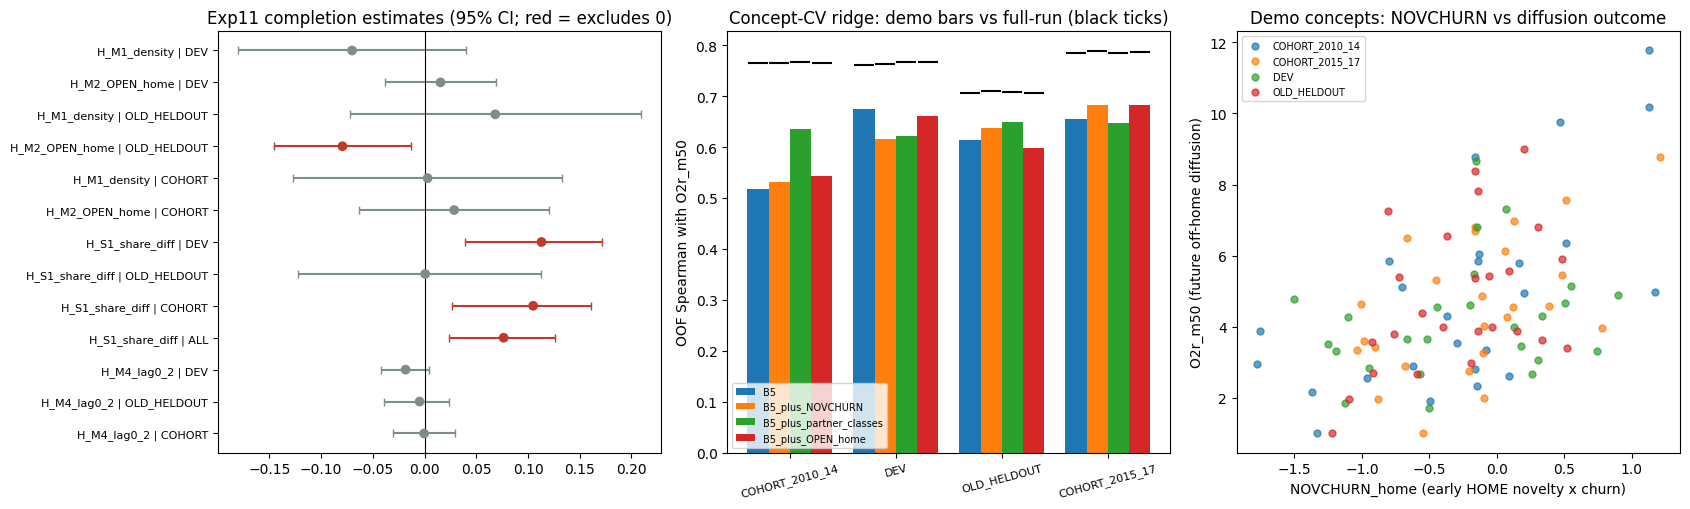

In [12]:
# ---- (1) Exp11 completion summary
print("Seal (G0):", comp["seal_verification"])
print("Panel rebuild == cache:", comp.get("panel_rebuild_equal_to_cache"), "| G1 DEV reproduction:", comp.get("G1_dev_reproduction"))
print("Exp11 unit tests:", comp.get("exp11_unit_tests_rerun"))
print(comp["dev_verdict"])
rows = []
for b, r in comp["body_models"].items():
    for h in ("H_M1_density", "H_M2_OPEN_home"):
        rows.append({"body": b, "test": h, "b": r[h]["b"], "lo": r[h]["ci_crv1"][0], "hi": r[h]["ci_crv1"][1],
                     "n_concepts": r["n_concepts"]})
for b, r in comp.get("H_S1", {}).items():
    rows.append({"body": b, "test": "H_S1_share_diff", "b": r["diff"], "lo": r["ci"][0], "hi": r["ci"][1], "n_concepts": r["n_multi"] + r["n_single"]})
for b, r in comp.get("event_study", {}).items():
    pv = r.get("primary_never")
    if pv and pv.get("mean_lag_0_2") is not None:
        rows.append({"body": b, "test": "H_M4_lag0_2", "b": pv["mean_lag_0_2"], "lo": pv["lag02_ci"][0], "hi": pv["lag02_ci"][1], "n_concepts": pv.get("n_treated")})
T = pd.DataFrame(rows)
T["excludes_0"] = (T.lo > 0) | (T.hi < 0)
print(T.round(4).to_string(index=False))

# ---- (2) Part-A CV metrics: demo vs full run
ref = data["reference_cv_metrics_full_run"]
models = ["B5", "B5_plus_NOVCHURN", "B5_plus_partner_classes", "B5_plus_OPEN_home"]
cv = []
for body, m in mo["metadata"]["cv_metrics"].items():
    for nm in models:
        cv.append({"body": body, "model": nm, "n_demo": m["n"], "spearman_demo": m[nm]["spearman_oof"],
                   "rmse_demo": m[nm]["rmse_oof"], "n_full": ref[body]["n"], "spearman_full": ref[body][nm]["spearman_oof"]})
CV = pd.DataFrame(cv)
print(CV.round(3).to_string(index=False))
print("\nNOVCHURN Spearman gain over B5 (demo est [95% boot CI] | full run est [CI]):")
for body, m in mo["metadata"]["cv_metrics"].items():
    gd, gf = m["gain_NOVCHURN_spearman"], ref[body]["gain_NOVCHURN_spearman"]
    print(f"  {body:<15} {gd['est']:+.4f} [{gd['ci'][0]:+.3f},{gd['ci'][1]:+.3f}]  |  {gf['est']:+.4f} [{gf['ci'][0]:+.4f},{gf['ci'][1]:+.4f}]")

# ---- figures
fig, ax = plt.subplots(1, 3, figsize=(17, 5.2))
yy = np.arange(len(T))[::-1]
col = np.where(T.excludes_0, "#c0392b", "#7f8c8d")
for yk, (bk, lo, hi, ck) in zip(yy, zip(T.b, T.lo, T.hi, col)):
    ax[0].errorbar(bk, yk, xerr=[[bk - lo], [hi - bk]], fmt="none", ecolor=ck, capsize=3)
ax[0].scatter(T.b, yy, c=col, zorder=3)
ax[0].axvline(0, color="k", lw=0.8)
ax[0].set_yticks(yy, [f"{a} | {b}" for a, b in zip(T.test, T.body)], fontsize=8)
ax[0].set_title("Exp11 completion estimates (95% CI; red = excludes 0)")

bodies = list(mo["metadata"]["cv_metrics"])
w = 0.2
for k, nm in enumerate(models):
    s = CV[CV.model == nm].set_index("body").loc[bodies]
    ax[1].bar(np.arange(len(bodies)) + (k - 1.5) * w, s.spearman_demo, w, label=nm)
    ax[1].scatter(np.arange(len(bodies)) + (k - 1.5) * w, s.spearman_full, marker="_", s=200, color="k", zorder=3)
ax[1].set_xticks(np.arange(len(bodies)), bodies, rotation=15, fontsize=8)
ax[1].set_ylabel("OOF Spearman with O2r_m50")
ax[1].set_title("Concept-CV ridge: demo bars vs full-run (black ticks)")
ax[1].legend(fontsize=7, loc="lower left")

ex = pd.DataFrame(mo["datasets"][0]["examples"])
ex["y"] = ex.output.astype(float)
for body, g in ex.groupby("metadata_body"):
    ax[2].scatter(g.metadata_NOVCHURN_home, g.y, label=body, alpha=0.7, s=25)
ax[2].set_xlabel("NOVCHURN_home (early HOME novelty x churn)")
ax[2].set_ylabel("O2r_m50 (future off-home diffusion)")
ax[2].set_title("Demo concepts: NOVCHURN vs diffusion outcome")
ax[2].legend(fontsize=7)
plt.tight_layout()
plt.show()